## Revisiting the LSTM

In [1]:
### importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### importing the key
load_dotenv('../keys.txt')
key = os.getenv('key')

### Defining the functions and working with them

In [3]:
### targeting only the features ['close', 'high', 'low' and 'open']
features_to_target = ['close', 'high', 'low', 'open']

In [4]:
### function to load the stock price
def load_stock_price(symbol, features_to_target) : 

    df = pdr.get_data_tiingo(symbol, api_key = key)
    df = df[features_to_target].reset_index(drop = True)

    return df

In [5]:
stock_boeing = load_stock_price('BA', features_to_target)
stock_boeing.tail()

,close,high,low,open
1250,230.72,231.330,227.070000,231.05
1251,224.11,230.255,221.150000,230.22
1252,229.03,229.550,224.612027,225.90
1253,227.38,231.510,227.260000,230.40
1254,221.30,227.870,221.040000,226.49


In [6]:
stock_apple = load_stock_price('AAPL', features_to_target)
stock_apple.tail()

,close,high,low,open
1250,270.71,273.23,268.6600,272.335
1251,270.17,271.04,267.0400,267.550
1252,271.35,276.00,268.1400,270.500
1253,280.14,287.22,278.3700,278.855
1254,276.83,280.63,274.8601,279.655


In [7]:
### function to plot the graphs for the scaled and non scaled data as the comparison
def plot_graphs(df, df_scaled = None) : 

    if df_scaled is not None : 

        for column in df.columns : 
                
            plt.figure(figsize = (8, 4))
            plt.subplot(1, 2, 1)
            plt.title(f"Before scaling :  {column}")
            plt.plot(df[column])
            plt.subplot(1, 2, 2)
            plt.title(f"After scaling :  {column}")
            plt.plot(df_scaled[column])


    else : 
        
        for column in df.columns : 
            plt.figure(figsize = (6, 4))
            plt.title(column)
            plt.plot(df[column])

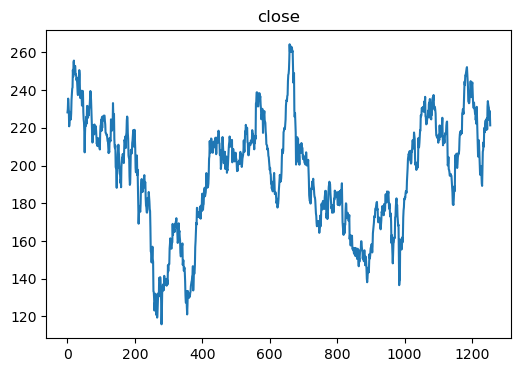

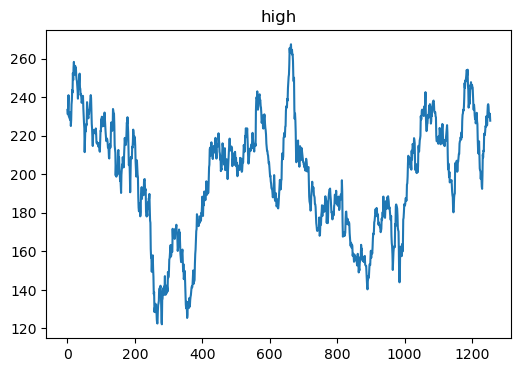

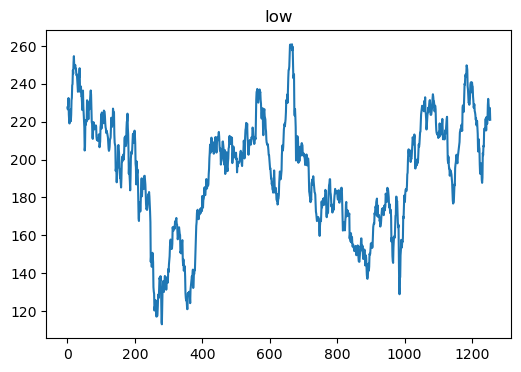

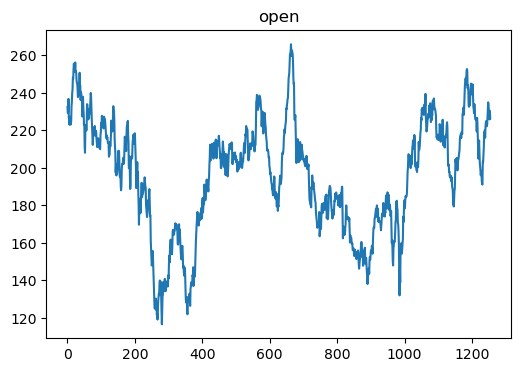

In [8]:
### plotting the graphs for the 'stock_boeing'
plot_graphs(stock_boeing)

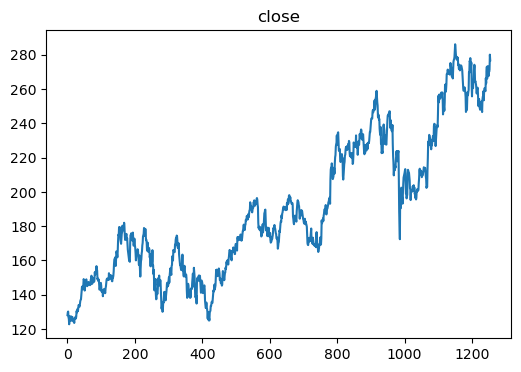

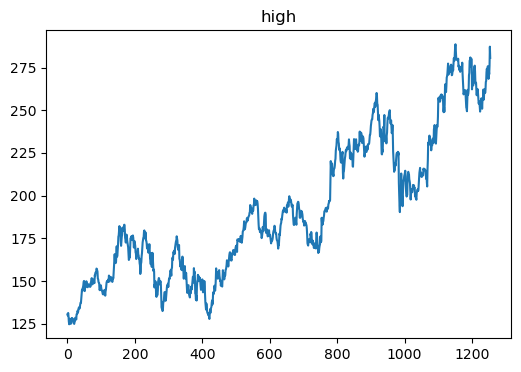

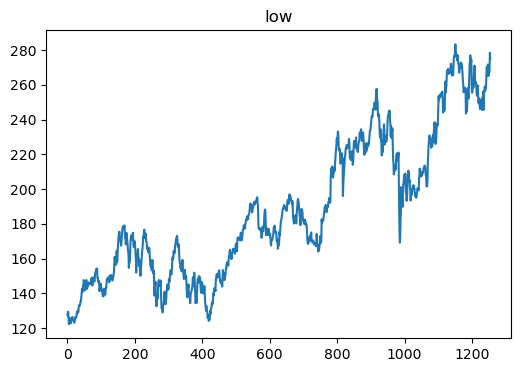

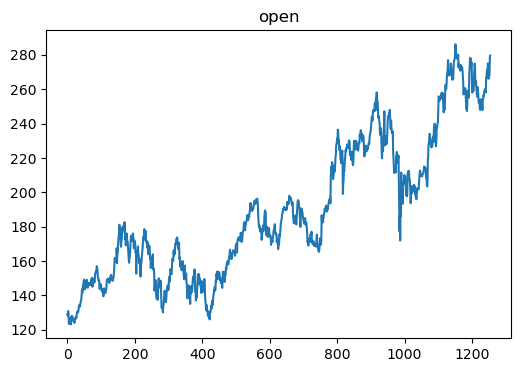

In [9]:
### plotting the graphs for the 'stock_apple'
plot_graphs(stock_apple)

In [10]:
### function to scale the data
def scale_data(df, scaler) : 

    df_scaled = scaler.fit_transform(df)
    df_scaled = pd.DataFrame(df_scaled, columns = df.columns)

    return df_scaled

In [11]:
### loading the scaler from the library
from sklearn.preprocessing import MinMaxScaler
scaler_apple = MinMaxScaler(feature_range = (0, 1))
scaler_boeing = MinMaxScaler(feature_range = (0, 1))

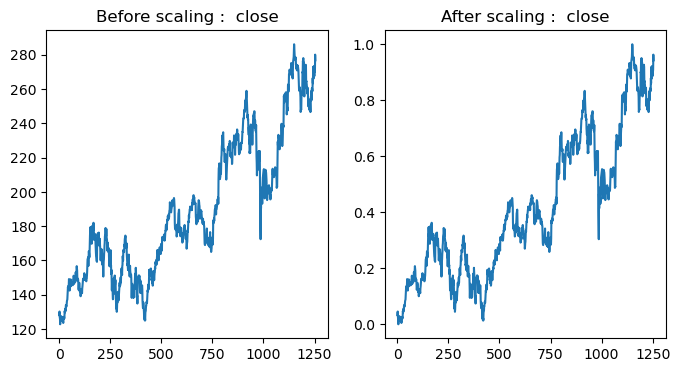

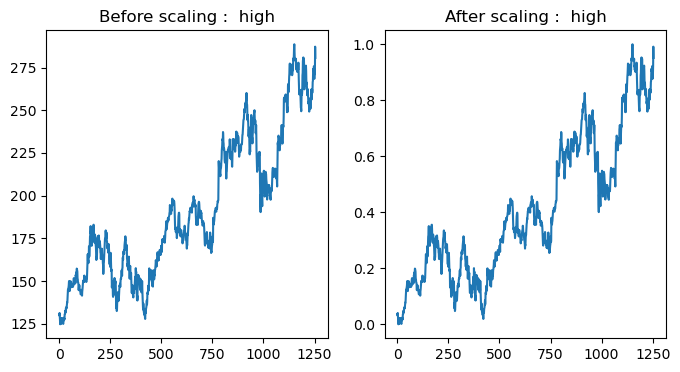

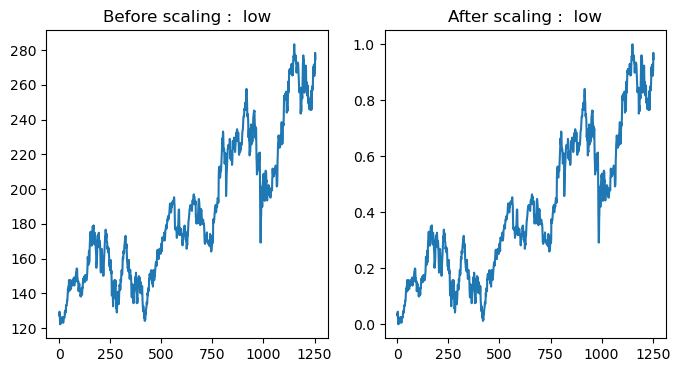

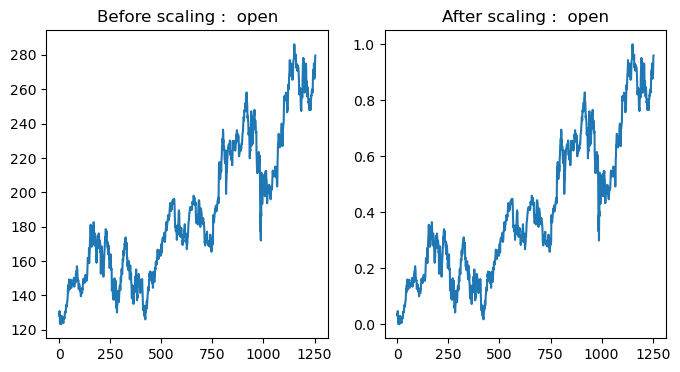

In [12]:
### scaling the data 'stock_apple' and the graphs for the comparison
stock_apple_scaled = scale_data(stock_apple, scaler = scaler_apple)
plot_graphs(stock_apple, stock_apple_scaled)

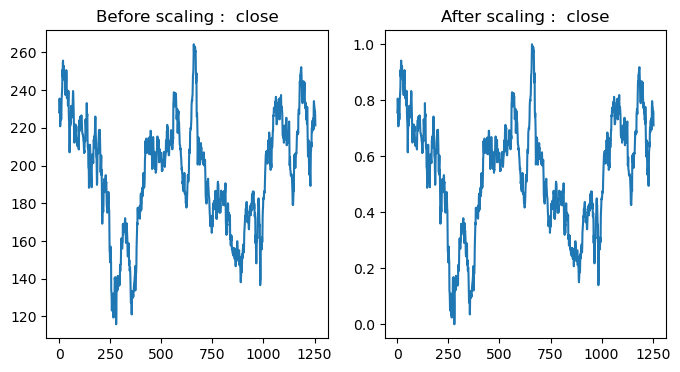

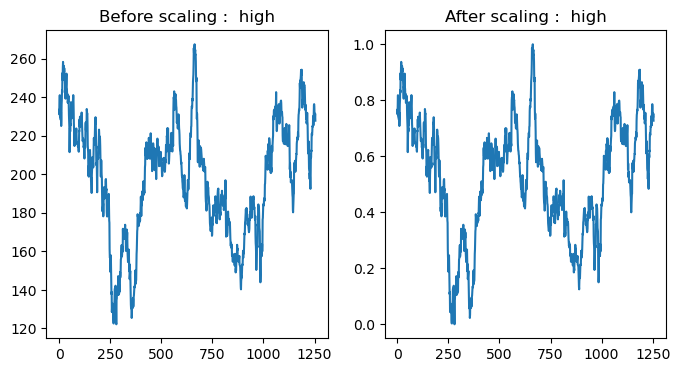

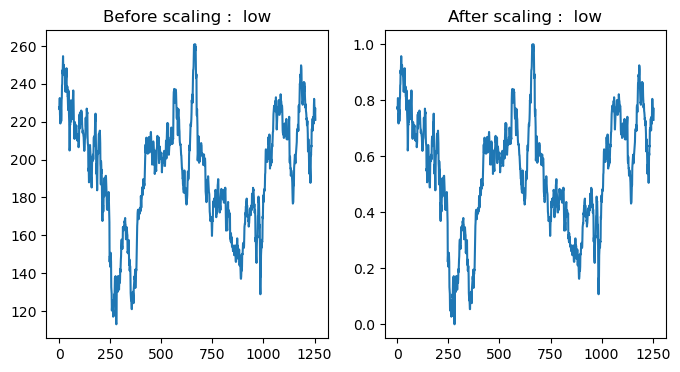

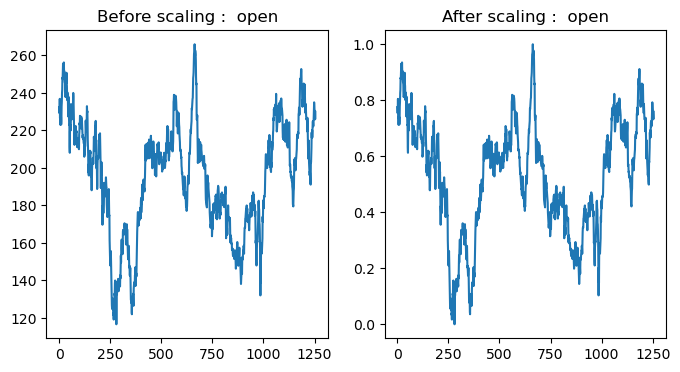

In [13]:
### scaling the data 'stock_boeing' and the graphs for the comparison
stock_boeing_scaled = scale_data(stock_boeing, scaler = scaler_boeing)
plot_graphs(stock_boeing, stock_boeing_scaled)

In [15]:
### importing the train test split library
from sklearn.model_selection import train_test_split

In [16]:
### function to create the sequences train and test sequences
def create_sequences(df, number_of_days) : 
    X, y = [], []

    for i in range(len(df) - number_of_days) : 

        X.append(df.iloc[i : i + number_of_days])
        y.append(df.iloc[i + number_of_days])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    print(f"{X_train.shape} :: {y_train.shape} \n{X_test.shape} :: {y_test.shape}")

    return X_train, X_test, y_train, y_test

In [17]:
### creating seuqnces for the apple stock price (90 days sequences)
X_train_apple, X_test_apple, y_train_apple, y_test_apple = create_sequences(stock_apple_scaled, number_of_days = 90)

(873, 90, 4) :: (873, 4) 
(292, 90, 4) :: (292, 4)


In [18]:
### creating seuqnces for the boeing stock price (90 days sequences)
X_train_boeing, X_test_boeing, y_train_boeing, y_test_boeing = create_sequences(stock_boeing_scaled, number_of_days = 90)

(873, 90, 4) :: (873, 4) 
(292, 90, 4) :: (292, 4)


In [19]:
### importing the libraries to create the sequeential model
import tensorflow
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional
from tensorflow.keras.models import Sequential

In [20]:
### function to create the model
def create_model(days) : 

    model = Sequential([
        LSTM(100, return_sequences = True, input_shape = (days, 4)),
        Dropout(0.33),
        Bidirectional(LSTM(200)),
        Dropout(0.21),
        Dense(4, activation = 'linear')
    ])
    model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])
    
    model.summary()

    return model

In [21]:
### crate the model for the 'stock_apple' 
model_apple = create_model(90)

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
### creating the model for the 'stock_boeing'
model_boeing = create_model(90)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

### model_apple training and testing

In [23]:
### training of the 'model_apple'
model_apple.fit(X_train_apple, y_train_apple, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0559 - mse: 0.0559
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0051 - mse: 0.0051
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0043 - mse: 0.0043
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0042 - mse: 0.0042
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0039 - mse: 0.0039
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0031 - mse: 0.0031
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0031 - mse: 0.0031
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0031 - mse: 0.0031
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0045 - mse: 0.0045
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0032 - mse: 0.0032
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0029 - mse: 0.0029
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0030 - mse: 0.0030
Epoch 13/40
28/28 ━━━━━━━

In [24]:
### predictions on the 'X_test_apple' 
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_apple

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


array([[0.25486705, 0.25212604, 0.25194377, 0.2560507 ],
       [0.1261436 , 0.12179777, 0.11800985, 0.12240344],
       [0.77462196, 0.7797057 , 0.7798984 , 0.79033774],
       ...,
       [0.30753422, 0.30598444, 0.30562252, 0.31162402],
       [0.19857617, 0.1933389 , 0.1951512 , 0.19929703],
       [0.2964931 , 0.29256988, 0.29813236, 0.3014398 ]], dtype=float32)

In [25]:
### shape checking
y_pred_apple.shape

(292, 4)

In [26]:
### inverse scaling the both
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

In [27]:
### checking the y_pred_apple
y_pred_apple

array([[164.42038, 165.98363, 162.82555, 164.90651],
       [143.38438, 144.6124 , 141.25548, 143.11665],
       [249.35872, 252.49614, 247.85263, 252.01668],
       ...,
       [173.02724, 174.81532, 171.4705 , 173.96718],
       [155.22131, 156.34372, 153.6791 , 155.65338],
       [171.2229 , 172.61562, 170.26422, 172.30673]], dtype=float32)

In [28]:
### y_test_apple
y_test_apple

array([[169.68  , 169.85  , 167.8801, 168.49  ],
       [146.83  , 147.08  , 145.64  , 146.65  ],
       [258.27  , 261.95  , 258.21  , 259.17  ],
       ...,
       [171.1   , 173.06  , 170.65  , 171.88  ],
       [157.83  , 162.14  , 157.81  , 159.3   ],
       [175.6   , 175.73  , 172.    , 172.17  ]])

In [29]:
### functions to plot the metrices and the graphs to check the model's performances
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
def metrices_and_graphs(y_test, y_pred) : 

    print(f"mean_absolute_error : {mean_absolute_error(y_test, y_pred)}")
    print(f"root_mean_squared_error : {root_mean_squared_error(y_test, y_pred)}")
    print(f"mean_squared_error : {mean_squared_error(y_test, y_pred)}")

    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

mean_absolute_error : 3.715047118304528
root_mean_squared_error : 4.881396056915532
mean_squared_error : 23.82802746447051


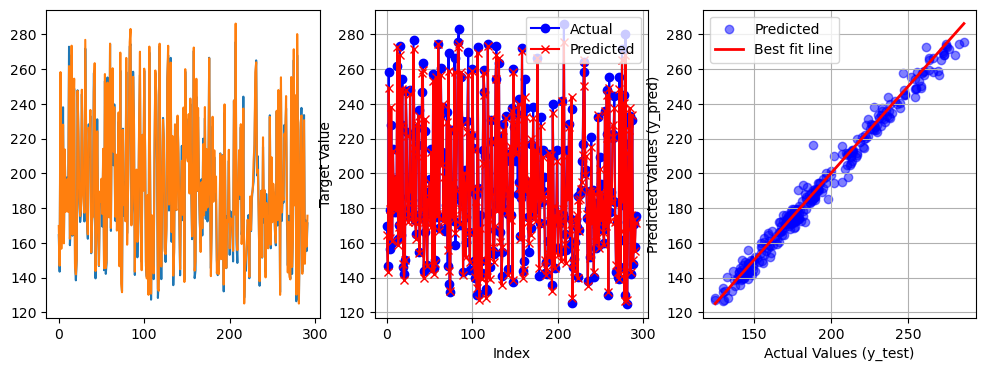

mean_absolute_error : 3.2782076409744882
root_mean_squared_error : 4.276266690699894
mean_squared_error : 18.286456809989424


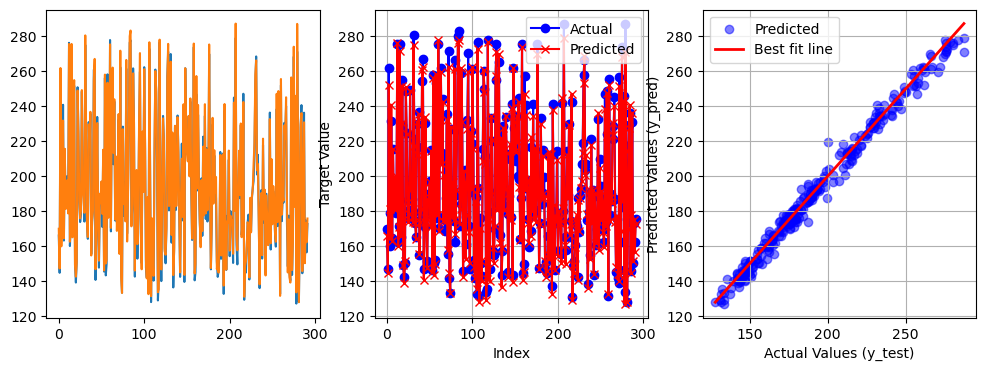

mean_absolute_error : 3.318047339291925
root_mean_squared_error : 4.499931069999322
mean_squared_error : 20.249379634745246


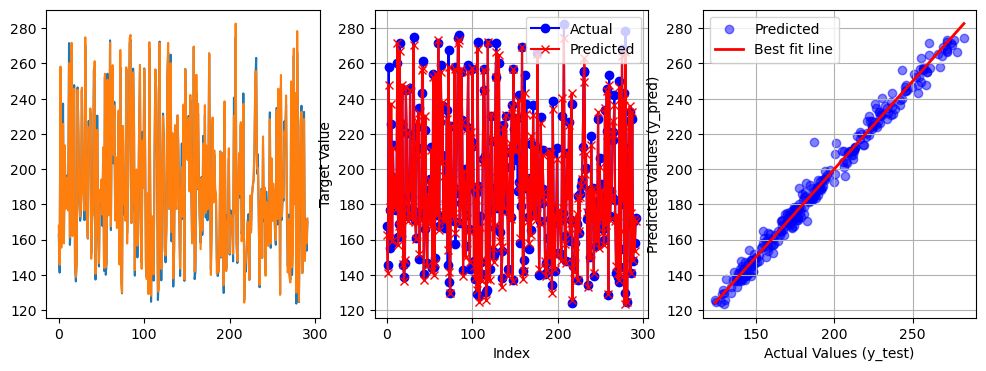

mean_absolute_error : 2.9815054743518563
root_mean_squared_error : 4.041700454301452
mean_squared_error : 16.335342562300568


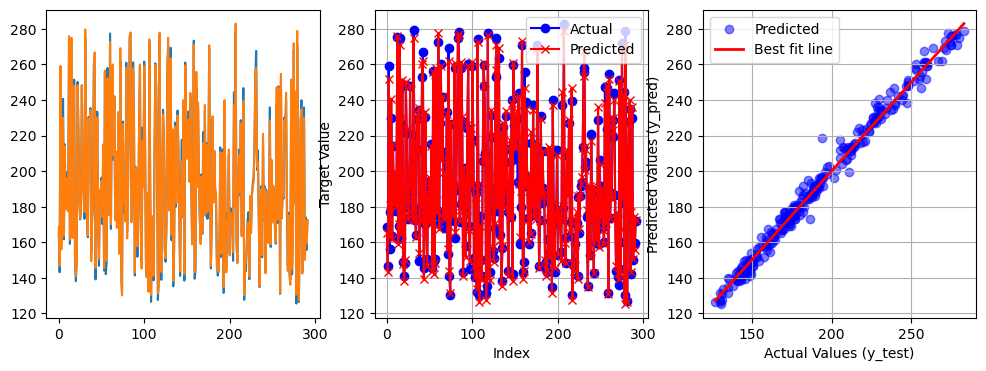

In [30]:
### checking the metrices and graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_apple[:, i], y_pred_apple[:, i])

### model_boeing training and testing

In [31]:
### training the model
model_boeing.fit(X_train_boeing, y_train_boeing, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0765 - mse: 0.0765
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0089 - mse: 0.0089
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0070 - mse: 0.0070
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0060 - mse: 0.0060
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0052 - mse: 0.0052
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0047 - mse: 0.0047
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0046 - mse: 0.0046
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0046 - mse: 0.0046
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0044 - mse: 0.0044
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0042 - mse: 0.0042
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0044 - mse: 0.0044
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0037 - mse: 0.0037
Epoch 13/40
28/28 ━━━━━━━━━━

In [33]:
### predicting the y_pred_boeing
y_pred_boeing = model_boeing.predict(X_test_boeing)
y_pred_boeing

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.30674103, 0.2915612 , 0.30636075, 0.29681164],
       [0.59500647, 0.5880247 , 0.59527767, 0.58193195],
       [0.56002593, 0.55289096, 0.5633975 , 0.55163884],
       ...,
       [0.49493137, 0.4856159 , 0.50113153, 0.48834044],
       [0.6154783 , 0.60923046, 0.61942536, 0.60589075],
       [0.41804495, 0.40634924, 0.4190593 , 0.40989113]], dtype=float32)

In [34]:
### inverse scaling the datasets
y_pred_boeing = scaler_boeing.inverse_transform(y_pred_boeing)
y_test_boeing = scaler_boeing.inverse_transform(y_test_boeing)

mean_absolute_error : 4.17023426735238
root_mean_squared_error : 5.461981624624574
mean_squared_error : 29.833243267736503


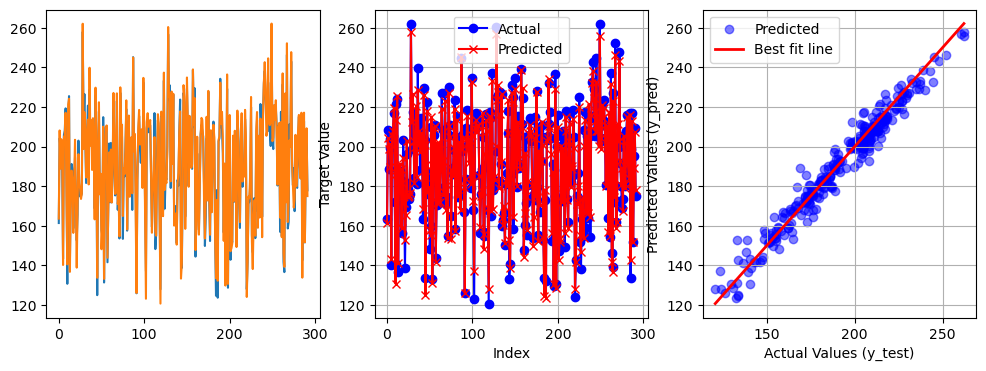

mean_absolute_error : 3.457772373230818
root_mean_squared_error : 4.4129215498390275
mean_squared_error : 19.473876605033688


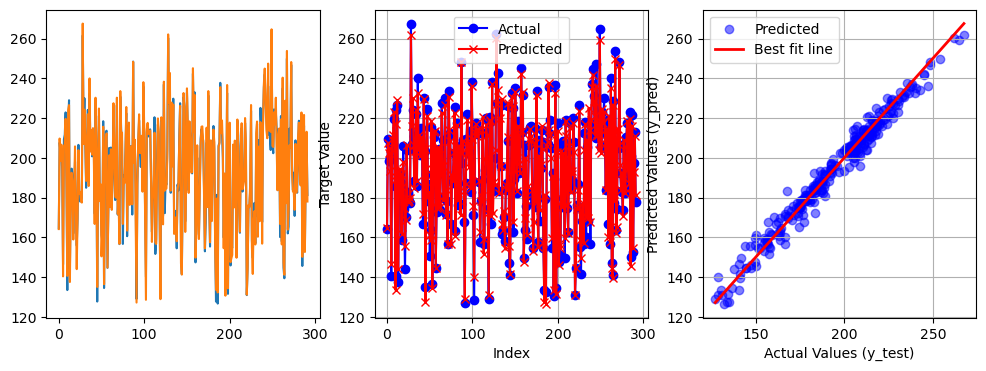

mean_absolute_error : 3.666701135128491
root_mean_squared_error : 4.835330704823424
mean_squared_error : 23.3804230250082


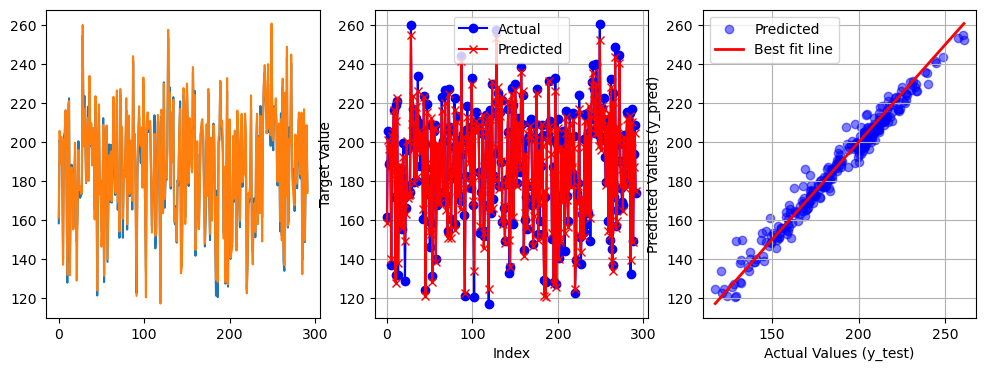

mean_absolute_error : 3.210740179819603
root_mean_squared_error : 4.199295660106852
mean_squared_error : 17.634084040992246


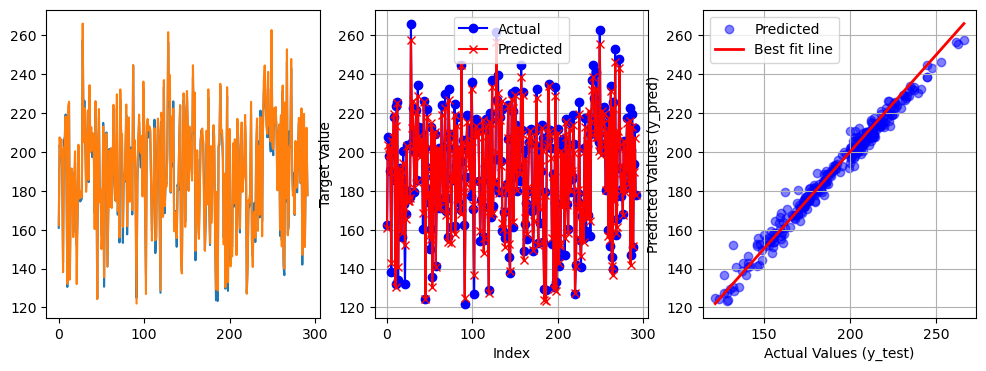

In [35]:
### checking the metrics and the graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_boeing[:, i], y_pred_boeing[:, i])

### new predictions

In [66]:
### function that predicts the price of future days
def pred_future(df, model, scaler, number_of_days) : 

    future_preds = []

    last_window = df[-number_of_days : ]
    last_window = np.array(last_window)

    last_window = np.expand_dims(last_window, axis = 0)

    for _ in range(number_of_days) : 

        next_pred = model.predict(last_window)
        future_preds.append(next_pred[0, :])

        next_pred_reshaped = np.expand_dims(next_pred, axis = 0)

        last_window = np.concatenate((last_window[:, 1 :, :], next_pred_reshaped), axis = 1)

    future_preds = scaler.inverse_transform(future_preds)

    return future_preds

In [68]:
### future_preds for the apple stock
future_preds_apple = pred_future(stock_apple_scaled, model_apple, scaler_apple, number_of_days = 90)
future_preds_apple

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

array([[273.91598837, 277.32318723, 272.47097884, 276.88535328],
       [274.10196547, 277.58119071, 272.58059357, 277.01945115],
       [273.76592482, 277.28101256, 272.1487006 , 276.62675886],
       [273.25989137, 276.77542465, 271.56196087, 276.06766626],
       [272.72848369, 276.23694734, 270.96484427, 275.47941984],
       [272.21659615, 275.71014993, 270.41318049, 274.9243116 ],
       [271.73063806, 275.20353576, 269.91996701, 274.41858022],
       [271.18388894, 274.66024966, 269.39114003, 273.89764026],
       [270.69572948, 274.16131783, 268.93469198, 273.43547441],
       [270.25559114, 273.70422836, 268.51555652, 273.02089731],
       [269.87603927, 273.30181448, 268.14532964, 272.6540839 ],
       [269.59100035, 273.01439136, 267.84125172, 272.33893106],
       [269.34050157, 272.75748257, 267.59213956, 272.06528356],
       [269.10408768, 272.52052245, 267.37256453, 271.81420111],
       [268.8636899 , 272.28283905, 267.16027539, 271.57252563],
       [268.59125531, 272

In [69]:
### future_preds for the boeing stock
future_preds_boeing = pred_future(stock_boeing_scaled, model_boeing, scaler_boeing, number_of_days = 90)
future_preds_boeing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

array([[223.17410431, 226.64854742, 220.30450541, 223.15763088],
       [221.59496511, 225.04929349, 218.70766525, 221.57917547],
       [220.11432528, 223.55293637, 217.22818795, 220.10821965],
       [218.76436631, 222.17290453, 215.88581764, 218.75865473],
       [217.55655251, 220.96144776, 214.68783494, 217.55497068],
       [216.42922778, 219.80296851, 213.56785911, 216.41693435],
       [215.46273083, 218.83182088, 212.61396298, 215.44327987],
       [214.5649844 , 218.04312729, 211.7619253 , 214.60216669],
       [213.63881602, 217.09291076, 210.84605421, 213.67356771],
       [212.73039257, 216.14727724, 209.92937219, 212.7486885 ],
       [211.84281896, 215.21712546, 209.03325402, 211.8384392 ],
       [211.05309897, 214.42463725, 208.24589593, 211.03702435],
       [210.38571814, 213.81622316, 207.58460046, 210.38067166],
       [209.79262538, 213.2763723 , 207.00008666, 209.79983566],
       [209.23465095, 212.73943238, 206.45333347, 209.24999479],
       [208.78774595, 212

In [71]:
### plotting the graphs for the both
future_index = np.arange(len(stock_apple), len(stock_apple) + len(future_preds_apple))
future_index

array([1255, 1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265,
       1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276,
       1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287,
       1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298,
       1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309,
       1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320,
       1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331,
       1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342,
       1343, 1344])

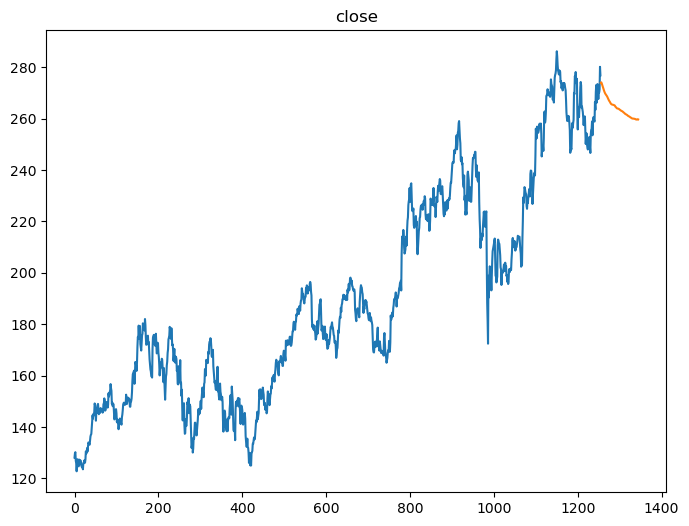

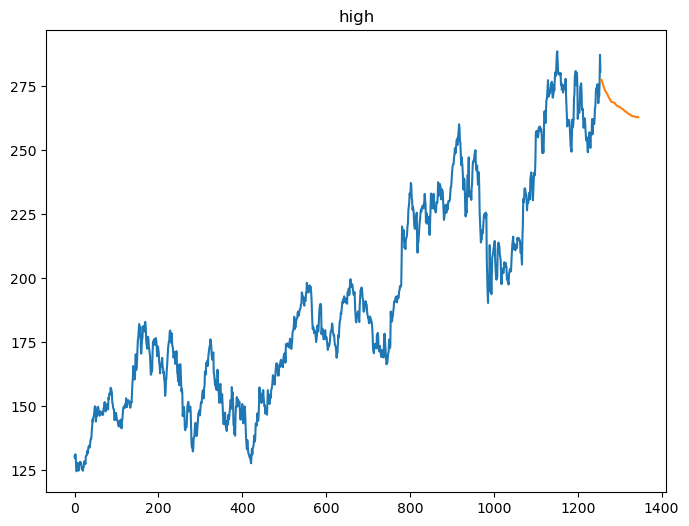

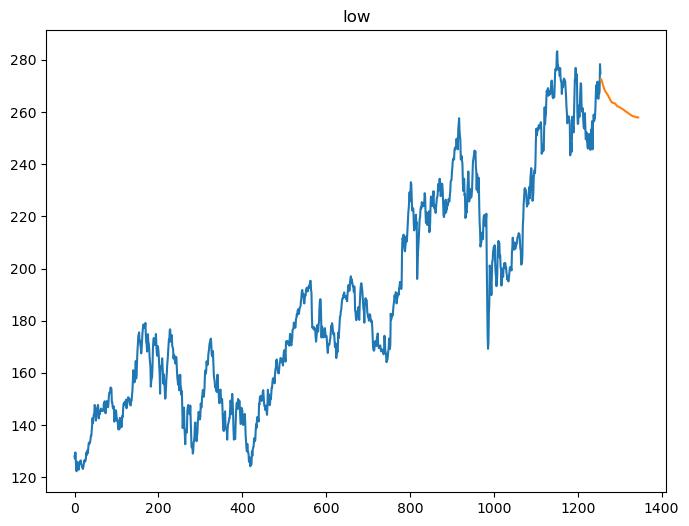

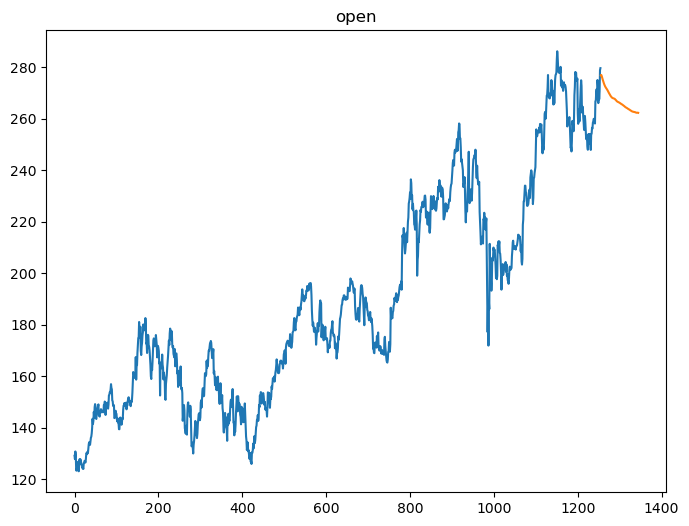

In [73]:
### plotting for the apple
for i in range(0, 4) : 

    plt.figure(figsize = (8, 6))
    plt.title(f"{features_to_target[i]}")
    plt.plot(stock_apple.index, stock_apple[features_to_target[i]])
    plt.plot(future_index, future_preds_apple[:, i])

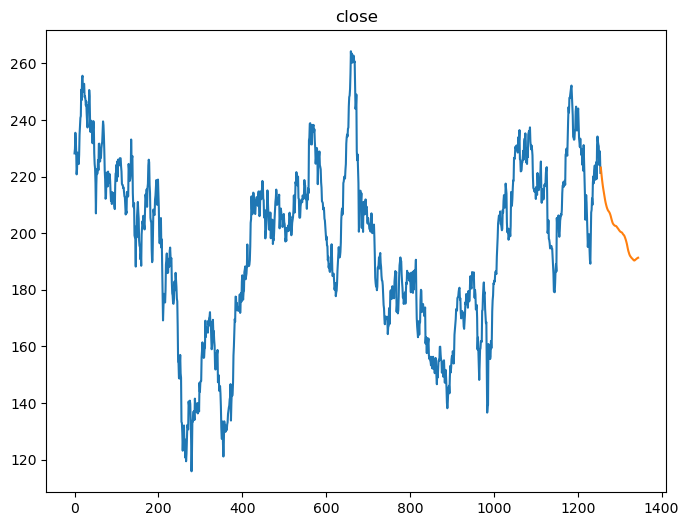

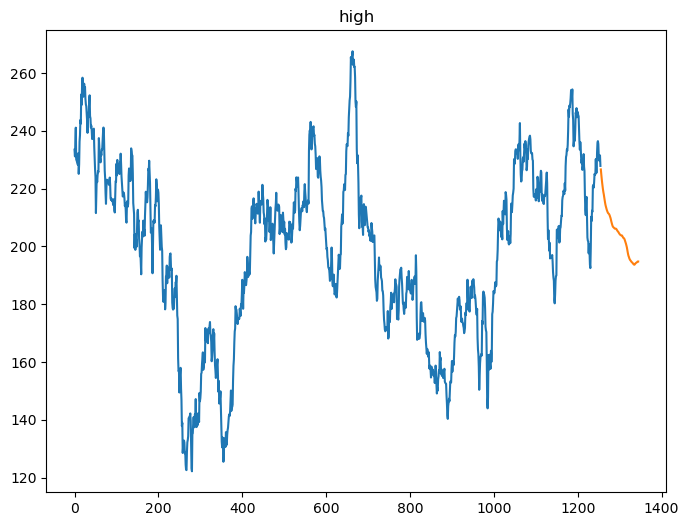

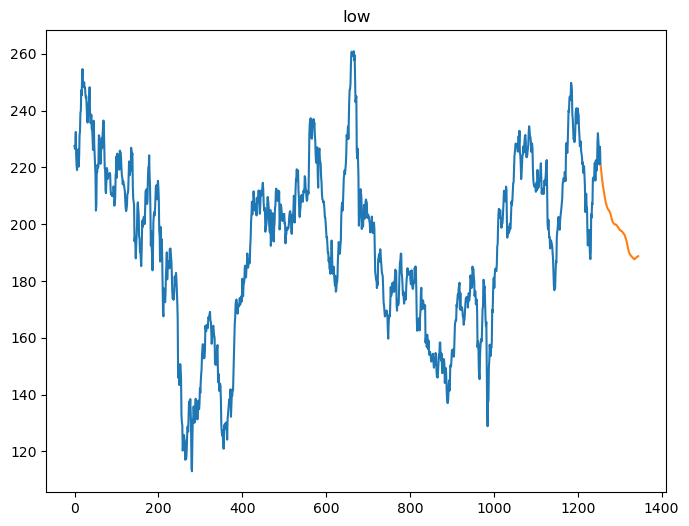

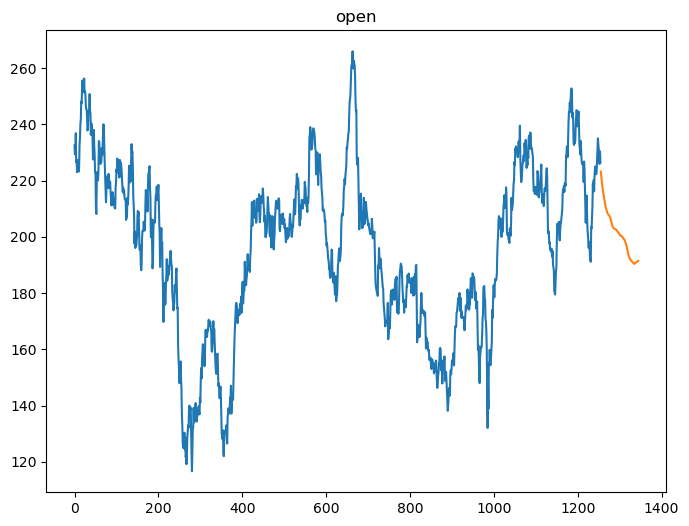

In [74]:
### plotting for the boeing, since the indexing stays the same
for i in range(0, 4) : 

    plt.figure(figsize = (8, 6))
    plt.title(f"{features_to_target[i]}")
    plt.plot(stock_boeing.index, stock_boeing[features_to_target[i]])
    plt.plot(future_index, future_preds_boeing[:, i])